### Exploratory Data Analysis

In [44]:
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
import numpy as np

from scipy.stats import chi2_contingency

DATA_FOLDER = "./data/"
OUTPUT_FOLDER = "./outputs/"
SEED = 404

warnings.filterwarnings('ignore')
%matplotlib inline

In [45]:
def apply_to_train_test(func):
    global train, test

    train, test = func(train), func(test)

In [46]:
def drop_columns(df: pd.DataFrame):
    return df.drop(columns=["Unnamed: 0", "Case_ID"])

def encode_y(df: pd.DataFrame):
    return df.replace({"GBM": 1, "LGG": 0})

In [47]:
train = pd.read_csv(DATA_FOLDER + "train.csv")
test = pd.read_csv(DATA_FOLDER + "test.csv")
apply_to_train_test(drop_columns)
train.head()

,Grade,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,GBM,Male,79 years 183 days,Glioblastoma,black or african american,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
1,LGG,Male,53 years 197 days,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED
2,LGG,Female,61 years 305 days,"Astrocytoma, NOS",white,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
3,LGG,Female,58 years 55 days,Mixed glioma,white,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
4,LGG,Male,30 years 113 days,"Astrocytoma, NOS",white,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED


### Пропущенные значения

In [48]:
print(train.isna().sum())

Grade                0
Gender               0
Age_at_diagnosis     0
Primary_Diagnosis    0
Race                 0
IDH1                 0
TP53                 0
ATRX                 0
PTEN                 0
EGFR                 0
CIC                  0
MUC16                0
PIK3CA               0
NF1                  0
PIK3R1               0
FUBP1                0
RB1                  0
NOTCH1               0
BCOR                 0
CSMD3                0
SMARCA4              0
GRIN2A               0
IDH2                 0
FAT4                 0
PDGFRA               0
dtype: int64


Ни один из признаков не содержит пропущенных значений, однако возможны "заглушки" со стороны провайдера данных, например, указание прочерка, пробела или какого-то другого заменителя вместо явного `None`

In [49]:
print("Shape of train data", train.shape)
print("Number of duplicates", train.duplicated().sum())
print("Unique values of each column:", pd.DataFrame(train.nunique()).to_markdown(), sep="\n")

Shape of train data (603, 25)
Number of duplicates 0
Unique values of each column:
|                   |   0 |
|:------------------|----:|
| Grade             |   2 |
| Gender            |   3 |
| Age_at_diagnosis  | 595 |
| Primary_Diagnosis |   7 |
| Race              |   6 |
| IDH1              |   2 |
| TP53              |   2 |
| ATRX              |   2 |
| PTEN              |   2 |
| EGFR              |   2 |
| CIC               |   2 |
| MUC16             |   2 |
| PIK3CA            |   2 |
| NF1               |   2 |
| PIK3R1            |   2 |
| FUBP1             |   2 |
| RB1               |   2 |
| NOTCH1            |   2 |
| BCOR              |   2 |
| CSMD3             |   2 |
| SMARCA4           |   2 |
| GRIN2A            |   2 |
| IDH2              |   2 |
| FAT4              |   2 |
| PDGFRA            |   2 |


['black or african american' 'white' 'not reported' 'asian' '--'
 'american indian or alaska native']
['Male' 'Female' '--']
['Glioblastoma' 'Astrocytoma, anaplastic' 'Astrocytoma, NOS'
 'Mixed glioma' 'Oligodendroglioma, anaplastic' 'Oligodendroglioma, NOS'
 '--']


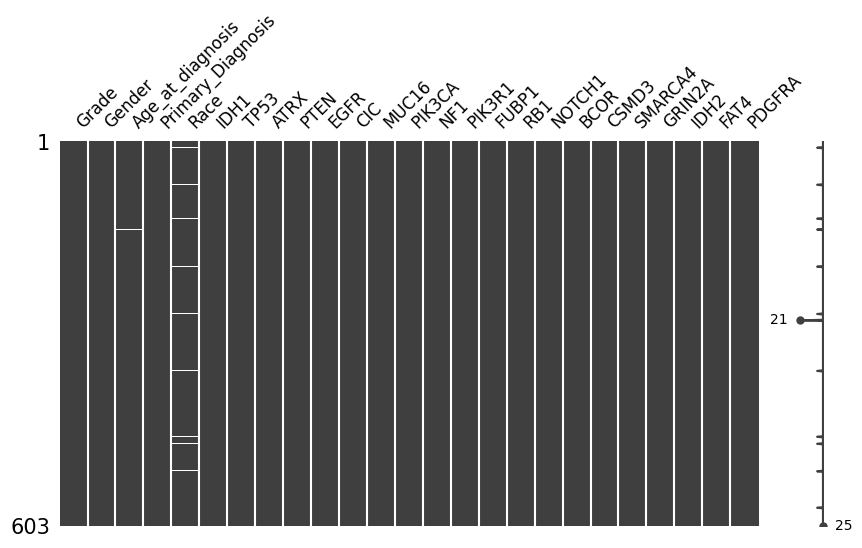

In [50]:
print(train["Race"].unique(), train["Gender"].unique(), train["Primary_Diagnosis"].unique(), sep="\n")

train = train.replace({"--": None, "not reported": None})

missingno.matrix(train, figsize=(10,5), fontsize=12);

Выходит, пропущенные значения все же есть, но их количество незначительно. Будем заменять их на медиану в численных признаках

In [51]:
def prepare_age(df: pd.DataFrame):
    df["Age_at_diagnosis"] = df["Age_at_diagnosis"].replace({"--": None, "not reported": None})
    df["Age_at_diagnosis"] = df["Age_at_diagnosis"].apply(lambda x: int(x.split(" ")[0]) if x else x)
    median = df["Age_at_diagnosis"].median(skipna=True)
    df["Age_at_diagnosis"] = df["Age_at_diagnosis"].fillna(int(median))
    return df

apply_to_train_test(prepare_age)
train.head(2)

,Grade,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,GBM,Male,79.0,Glioblastoma,black or african american,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
1,LGG,Male,53.0,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED


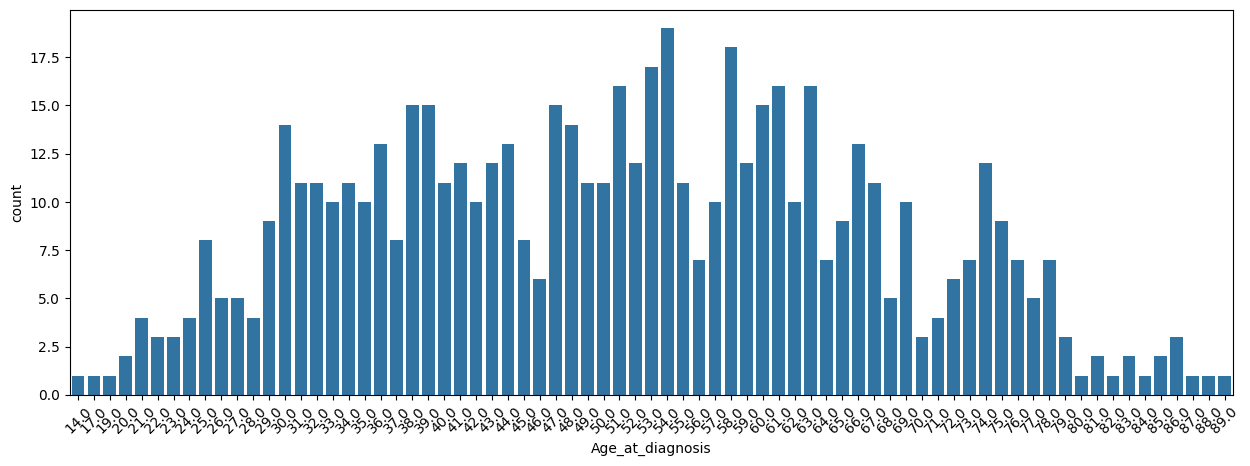

In [52]:
plt.figure(figsize=(15, 5))
sns.countplot(data=train.sort_values(by="Age_at_diagnosis"), x="Age_at_diagnosis")
plt.xticks(rotation=45);

### Диагноз и целевая переменная

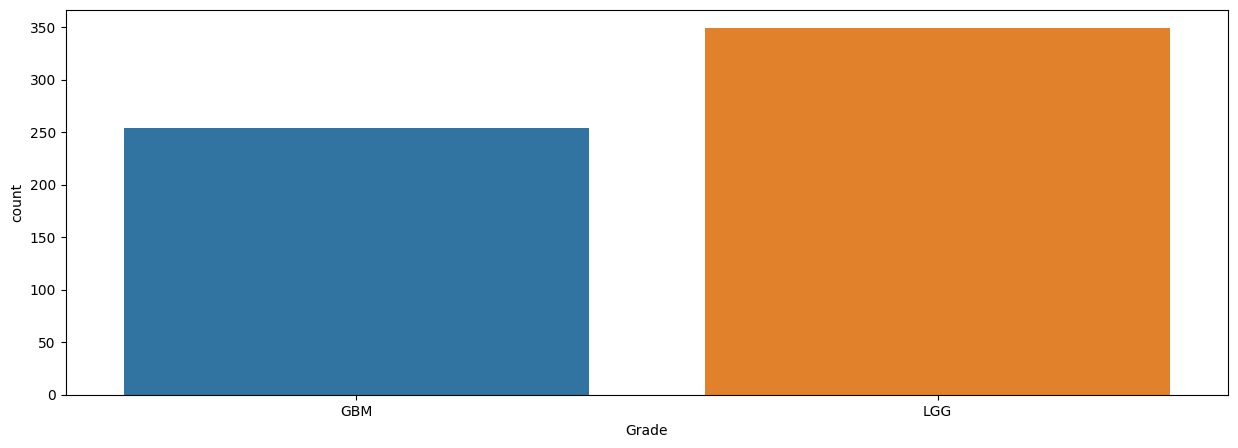

In [53]:
plt.figure(figsize=(15, 5))
sns.countplot(data=train, x="Grade", hue="Grade");

Оба класса относительно неплохо сбалансированы, так что в целом каких-то методов аугментации не требуется, по крайней мере в контексте распределения целевого признака.

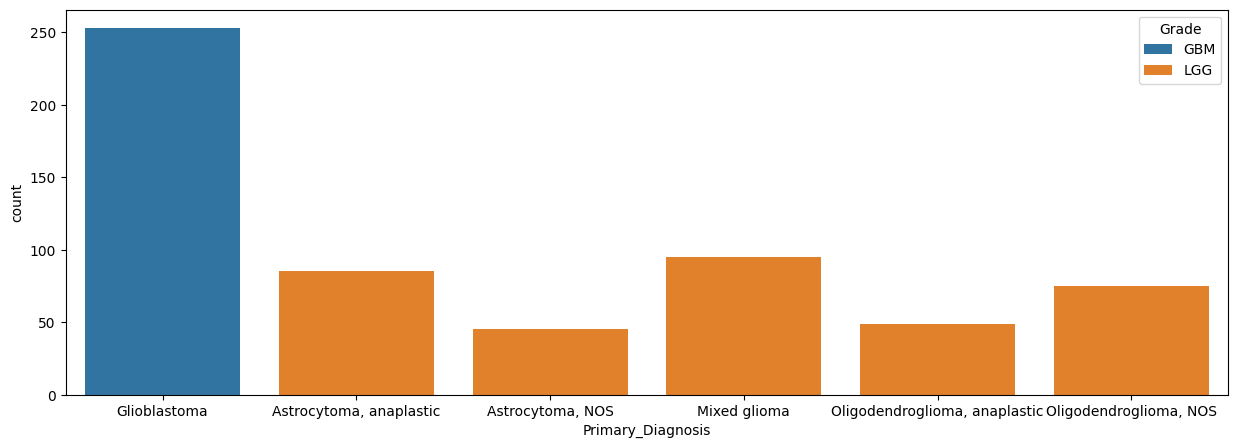

In [54]:
plt.figure(figsize=(15, 5))
sns.countplot(data=train, x="Primary_Diagnosis", hue="Grade");

Amount of unknown data: 3


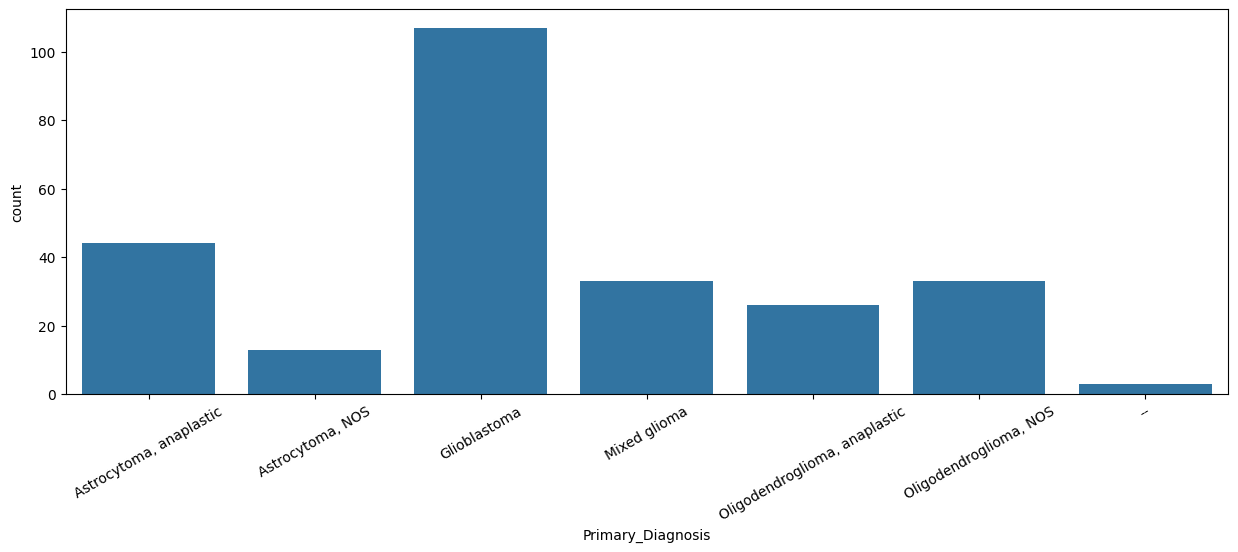

In [55]:
plt.figure(figsize=(15, 5))
plt.xticks(rotation=30)
sns.countplot(data=test, x="Primary_Diagnosis");
print("Amount of unknown data:", test[test["Primary_Diagnosis"] == "--"]["Primary_Diagnosis"].count())

### Зависимость типа опухоли от возраста

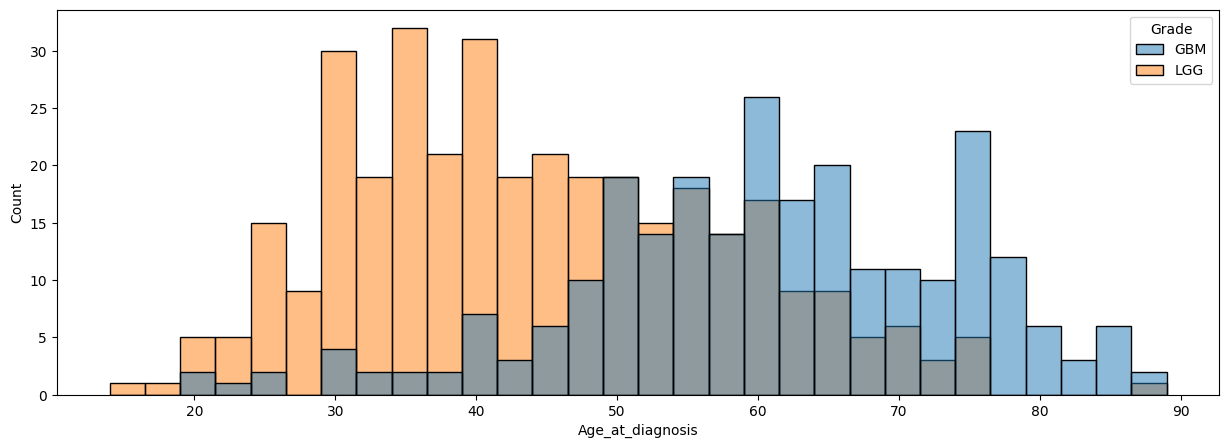

In [56]:
plt.figure(figsize=(15, 5))
sns.histplot(data=train, x="Age_at_diagnosis", hue="Grade", bins=30);

### Анализ мутаций генов

In [57]:
genes = list(train.drop(columns=["Grade", "Gender", "Age_at_diagnosis", "Primary_Diagnosis", "Race"]).columns)
assert len(genes) == 20

def get_mutated_features(row):
    mutated_features = []
    for feature in genes:
        if row[feature] == 'MUTATED':
            mutated_features.append(feature)
    return '_'.join(mutated_features) if mutated_features else 'NONE'

train["mutated_genes"] = train.apply(get_mutated_features, axis=1)

In [58]:
DROP_NUMBER = 1
cnt_mutated_genes = train.groupby(["mutated_genes", "Grade"])\
    .agg({"mutated_genes": "count"})\
    .rename(columns={"mutated_genes": "cnt"}).reset_index()
best_mutated_genes = cnt_mutated_genes[cnt_mutated_genes["cnt"] > DROP_NUMBER]

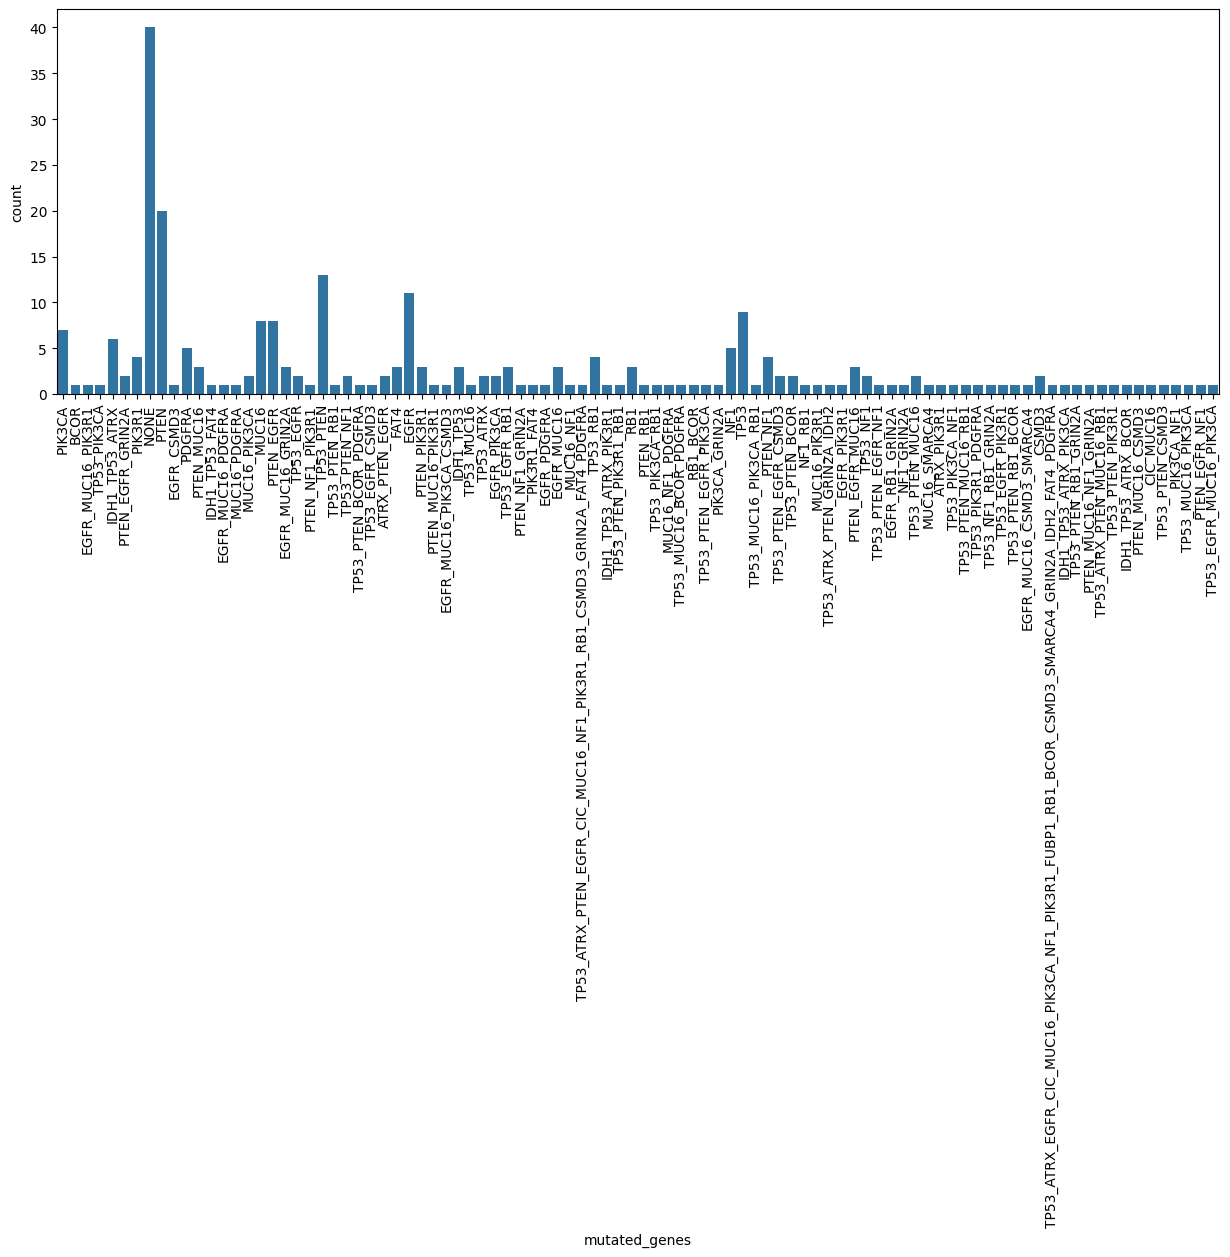

In [59]:
plt.figure(figsize=(15, 5))
sns.countplot(data=train[train.Grade == "GBM"], x="mutated_genes");
plt.xticks(rotation=90);

TODO: Написать вывод

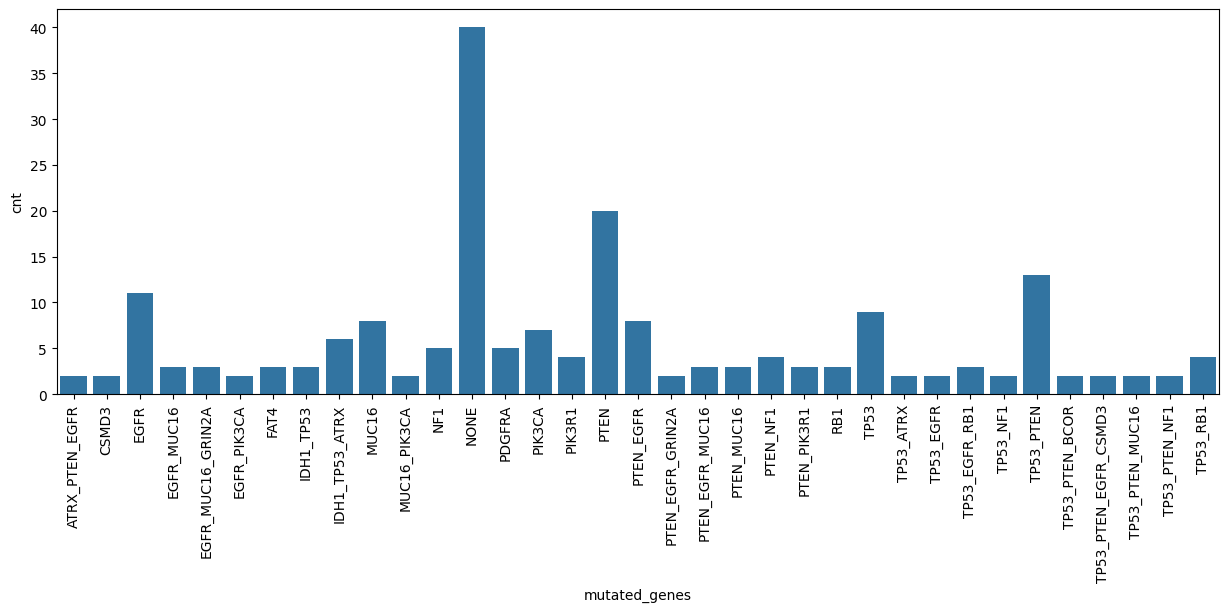

In [60]:
plt.figure(figsize=(15, 5))
sns.barplot(data=best_mutated_genes[best_mutated_genes["Grade"] == "GBM"], x="mutated_genes", y="cnt");
plt.xticks(rotation=90);

TODO: Написать вывод

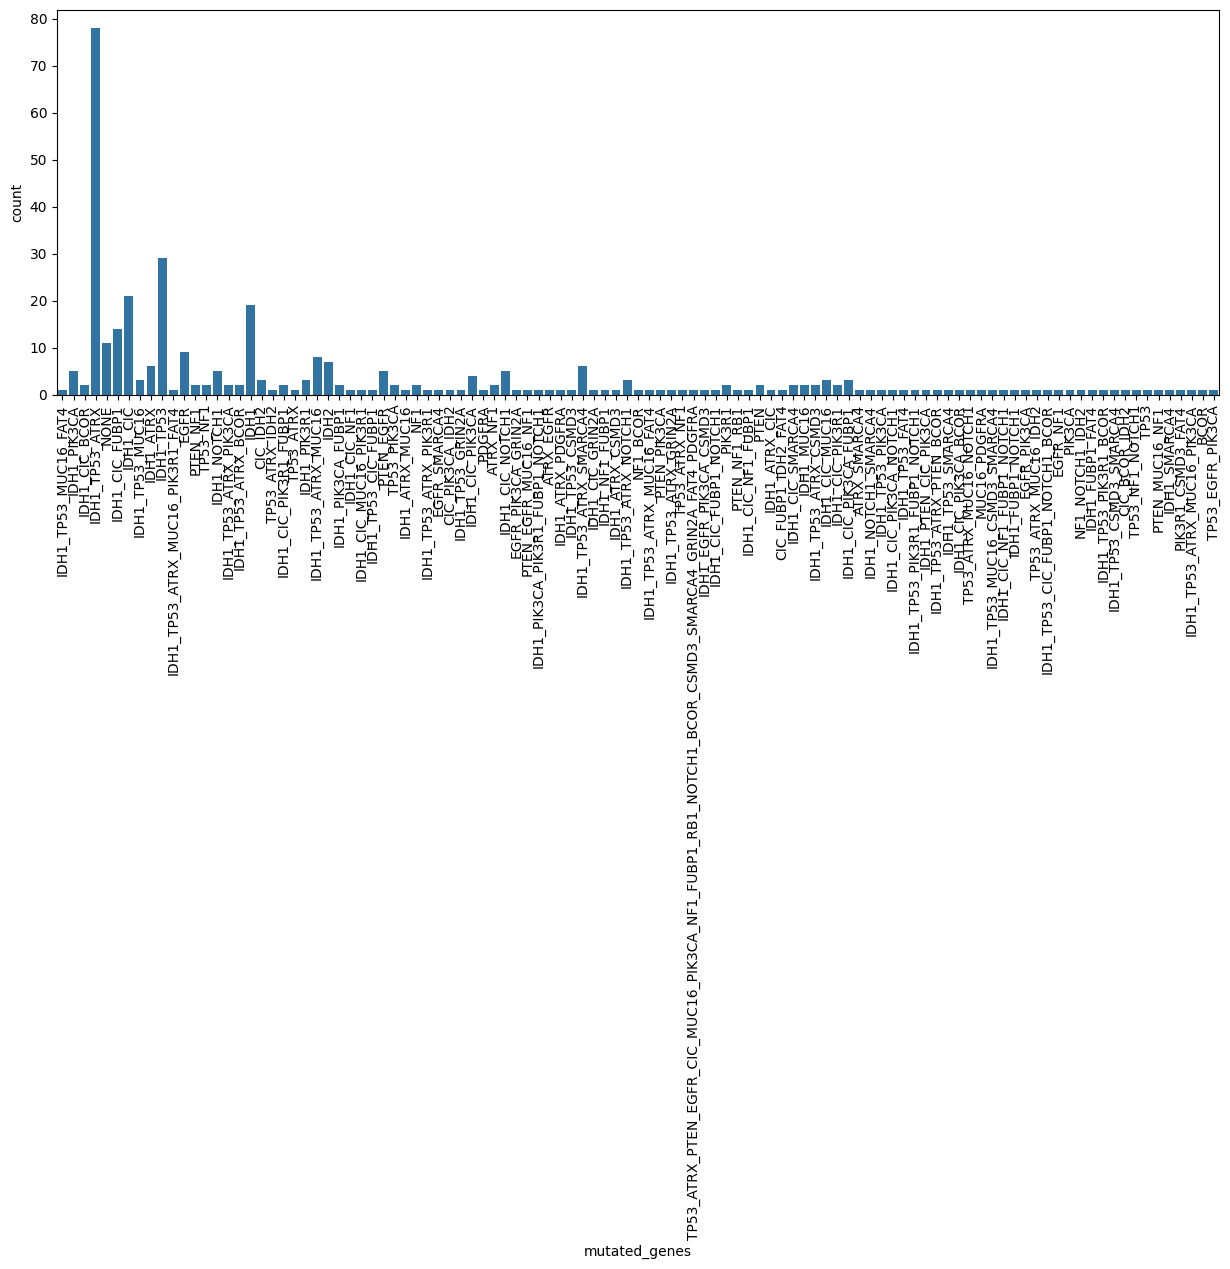

In [61]:
plt.figure(figsize=(15, 5))
sns.countplot(data=train[train.Grade == "LGG"], x="mutated_genes");
plt.xticks(rotation=90);

TODO: Написать вывод

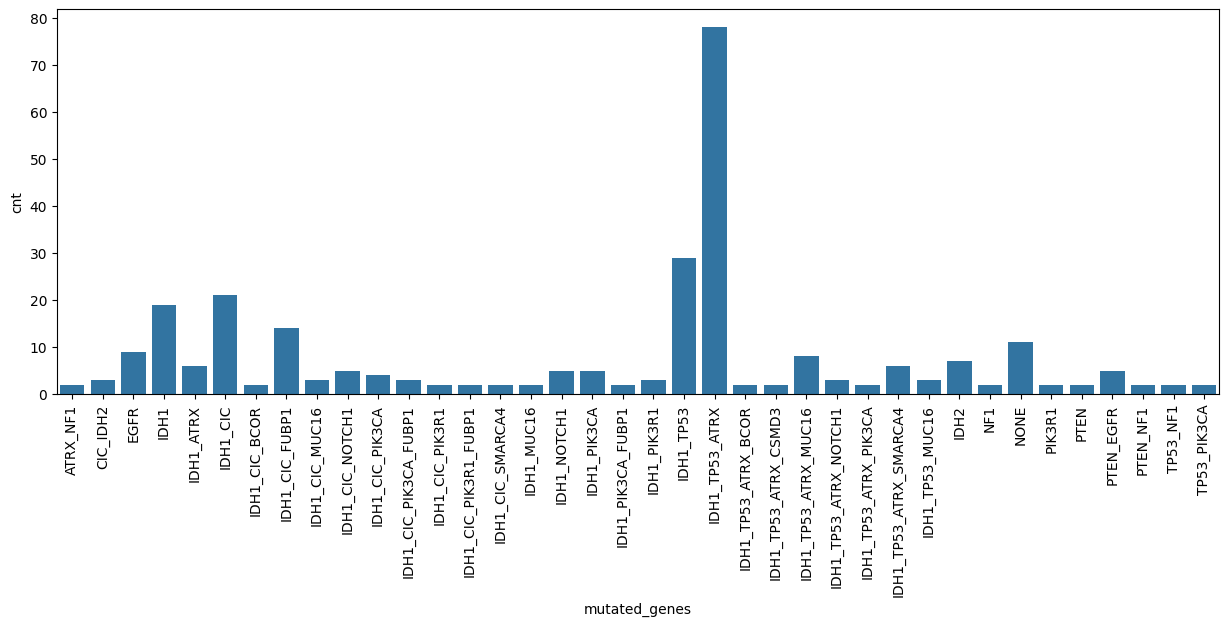

In [62]:
plt.figure(figsize=(15, 5))
sns.barplot(data=best_mutated_genes[best_mutated_genes["Grade"]=="LGG"], x="mutated_genes", y="cnt");
plt.xticks(rotation=90);

TODO: написать вывод

### Анализ мультиколлинеарности

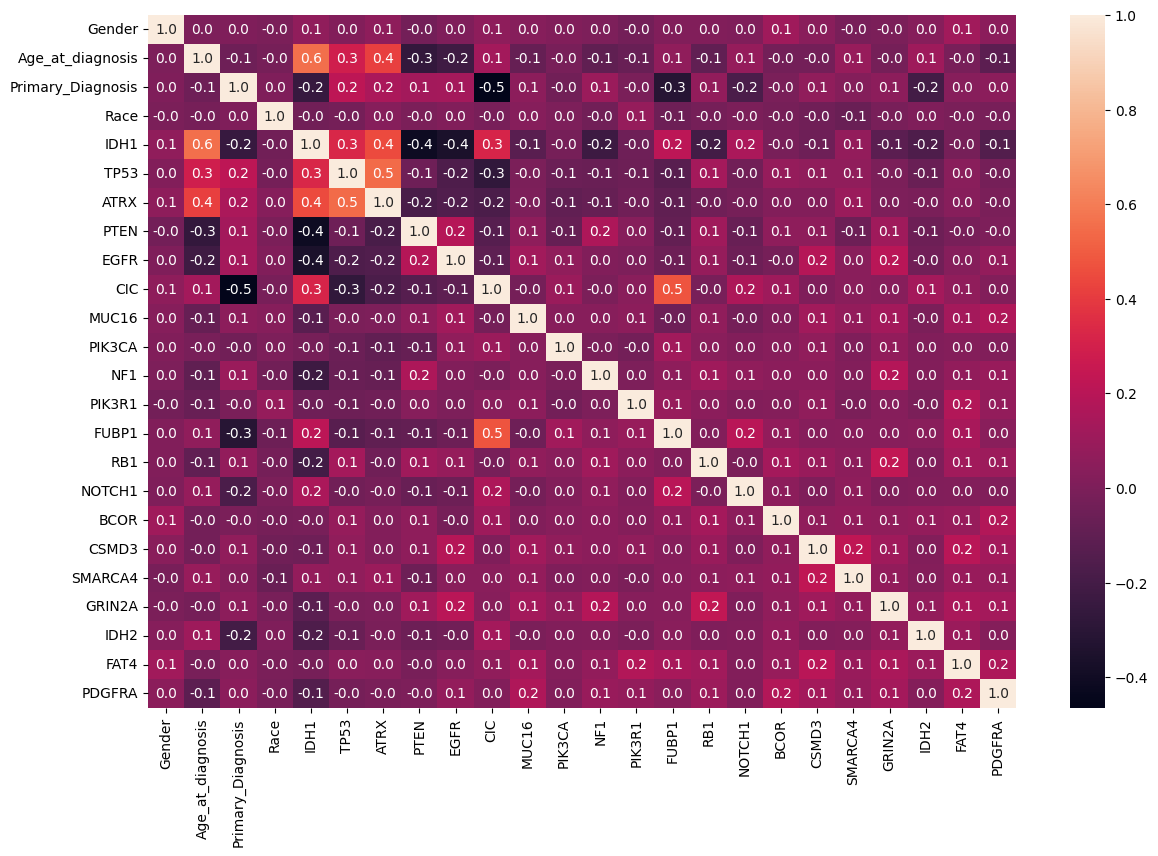

In [78]:
from sklearn.preprocessing import LabelEncoder

encoded_train = train
for column in encoded_train.columns[encoded_train.dtypes == "object"]:
    encoded_train[column] = LabelEncoder().fit_transform(
        encoded_train[column]
    )

# drop column from previous analysis and target column
encoded_train = encoded_train.drop(columns=["mutated_genes", "Grade"])


plt.figure(figsize=(14, 9))
sns.heatmap(pd.DataFrame(data=encoded_train).corr(method="pearson"), annot=True, fmt=".1f")
plt.show()

Исходя из матрицы корреляций Пирсона можно заключить, что значимой мультиколлинеарности, способной существенно увеличить неустойчивость оценок параметров - нет.

Рассмотрим еще два варианта корреляции

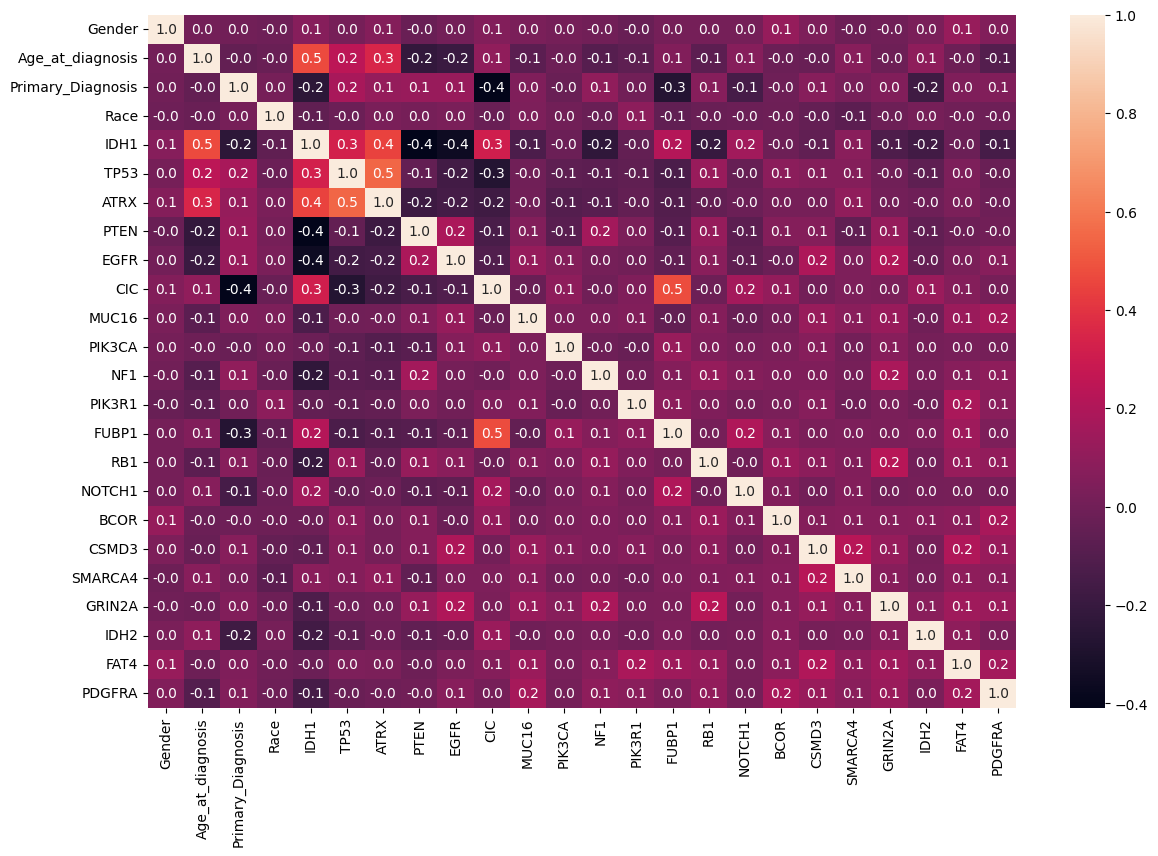

In [79]:
plt.figure(figsize=(14, 9))
sns.heatmap(pd.DataFrame(data=encoded_train).corr(method="kendall"), annot=True, fmt=".1f")
plt.show()

Строгого или даже просто сильного согласия или несогласия между признаками также не обнаружено

In [29]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

def cravers_corr_matrix(df):
    categories = df.columns
    corr_matrix = pd.DataFrame(np.zeros((len(categories), len(categories))), index=categories, columns=categories)

    for col1 in categories:
        for col2 in categories:
            if col1 == col2:
                corr_matrix.loc[col1, col2] = 1.0
            else:
                corr_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

    plt.figure(figsize=(8, 6))
    plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none', aspect='auto')

    plt.colorbar()

    plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
    plt.yticks(range(len(corr_matrix)), corr_matrix.columns)

    plt.title("Cramér's V Correlation Matrix for Categorical Features")

    plt.tight_layout()
    plt.show()

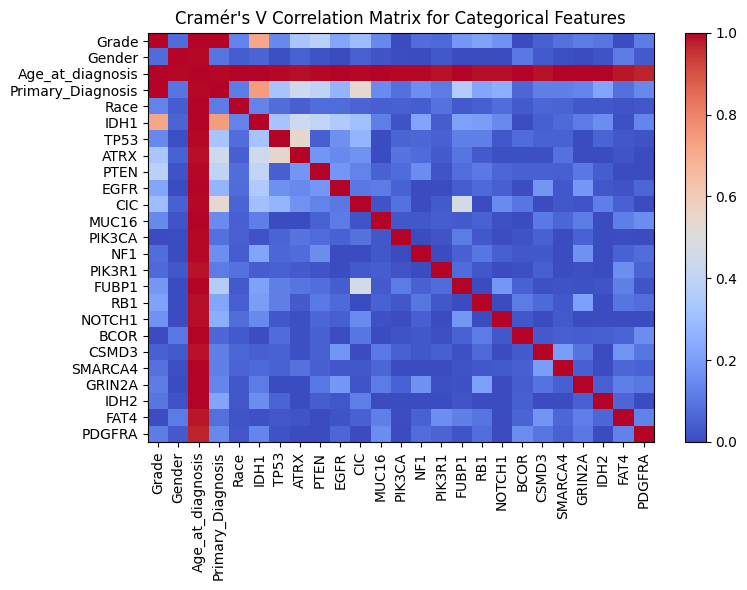

In [30]:
cravers_corr_matrix(train)

TODO: написать вывод